# Canada Food CPI — CFPR Replica Experiment

This notebook is a **LLMP methodology demonstration**: it compares direct LLM
process predictors to conventional baselines on historical Canadian food CPI
data and, crucially, explains what those comparisons can and cannot tell us.

**The leakage problem.** Frontier LLMs like Gemini were trained on data through
late 2024.  For most backtest origins here (2009–2024), the model has likely
been exposed to the resolved outcomes.  A strong CRPS score therefore tells us
the pipeline is working and the model can produce calibrated structured output
— it does not tell us the model can genuinely forecast the future.  The right
interpretation is an **upper bound**: if a model with perfect recall of
historical outcomes scores X, a live deployment should aspire to approach X on
unresolved tasks.

Set `EXPERIMENT_CONFIG` in the config cell to choose the scope:
`mini_single` (1 target, 6 origins), `mini_recent` (9 targets, 6 origins — default),
or `full` (9 targets, 16 origins — canonical CFPR backtest).

**What's here:**

1. Data overview — nine food CPI sub-indices at a glance.
2. Spec + LLMP predictors — loaded from YAML; backtest results cached on disk.
3. Qualitative check — trajectory fans and avg/avg YoY grid.
4. Model selection — CRPS and MAPE per category.
5. What next — why live forecasting is the only clean evaluation.


---
## 1. Setup

The heavy lifting lives in helper modules alongside this notebook:

- `data.py`      registers the 9 StatCan series on a `DataService`.
- `analysis.py`  flattens results to DataFrames and computes avg/avg YoY.
- `plots.py`     renders the figures the CFPR audience expects.

Backtest specs (all under `implementations/food_price_forecasting/specs/`):

| Spec file | Tasks | Origins | Notes |
|---|---|---|---|
| `food_cpi_single_mini_backtest.yaml` | 1 (food overall) | 6 (2019–2024) | Fast dev/smoke-test |
| `food_cpi_recent_backtest.yaml` | 9 | 6 (2019–2024) | Recent regimes only |
| `food_cpi_cfpr_backtest.yaml` | 9 | 16 (2009–2024) | Canonical CFPR backtest |

There is no protected eval spec for this experiment — historical LLM scores are upper bounds on live performance (see the intro).

Run the data fetch once if you haven't:

```bash
uv run python scripts/fetch_cpi.py
```

In [1]:
from __future__ import annotations

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env")

import importlib

# Helper to live-reload the plots module during development
import food_price_forecasting
import food_price_forecasting.plots
from aieng.forecasting.evaluation import (
    MultiTargetBacktestSpec,
    cached_multi_backtest,
    describe_spec,
)
from aieng.forecasting.methods import DartsAutoARIMAPredictor, LastValuePredictor
from food_price_forecasting.analysis import compute_ape_long, compute_avgyoy, compute_mape, summarize_crps
from food_price_forecasting.data import CATEGORY_LABELS, build_food_cpi_service


importlib.reload(food_price_forecasting.plots)
from food_price_forecasting.plots import (
    plot_avgyoy_grid,
    plot_food_cpi_small_multiples,
    plot_mape_by_category,
    plot_trajectory_fan,
)


STATCAN_CACHE = ROOT / "data" / "statcan"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
SPECS_DIR = ROOT / "implementations" / "food_price_forecasting" / "specs"
REPORTS_DIR = ROOT / "data" / "reports" / "cfpr"

# `reports_dir` attaches a cutoff-aware DocumentStore of CFPR editions, so the
# report-grounded quantile-grid recipe below can prepend each edition published
# on or before the forecast origin. Populate it once with
# `scripts/fetch_cfpr.py` then `scripts/extract_reports.py`; if the directory is
# absent the store simply loads empty and the numeric-only predictors are
# unaffected.
svc = build_food_cpi_service(cache_dir=STATCAN_CACHE, reports_dir=REPORTS_DIR)
print(f"Registered {len(CATEGORY_LABELS)} food CPI series.")

Registered 9 food CPI series.


In [2]:
# ── Experiment configuration ──────────────────────────────────────────────────
# Set EXPERIMENT_CONFIG to control which CFPR backtest runs throughout this
# notebook. All downstream cells adapt automatically.
#
#   "mini_single"  1 target (food overall) × 6 recent origins (Jul 2019–2024)
#                  fast smoke test for the active LLMP set
#   "mini_recent"  9 targets × 6 recent origins (Jul 2019–2024)
#                  default experiment; covers COVID/inflation regimes
#   "full"         9 targets × 16 origins (Jul 2009–2024)
#                  canonical CFPR backtest

EXPERIMENT_CONFIG = "mini_single"

_BACKTEST_SPEC_FILES = {
    "mini_single": "food_cpi_single_mini_backtest.yaml",
    "mini_recent": "food_cpi_recent_backtest.yaml",
    "full": "food_cpi_cfpr_backtest.yaml",
}
_BACKTEST_SPEC_FILE = _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]

print(f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILE}")

Config: 'mini_single'  →  food_cpi_single_mini_backtest.yaml


---
## 2. Data exploration

A single figure is plenty — the nine sub-indices track each other closely with
a clear post-2020 acceleration.

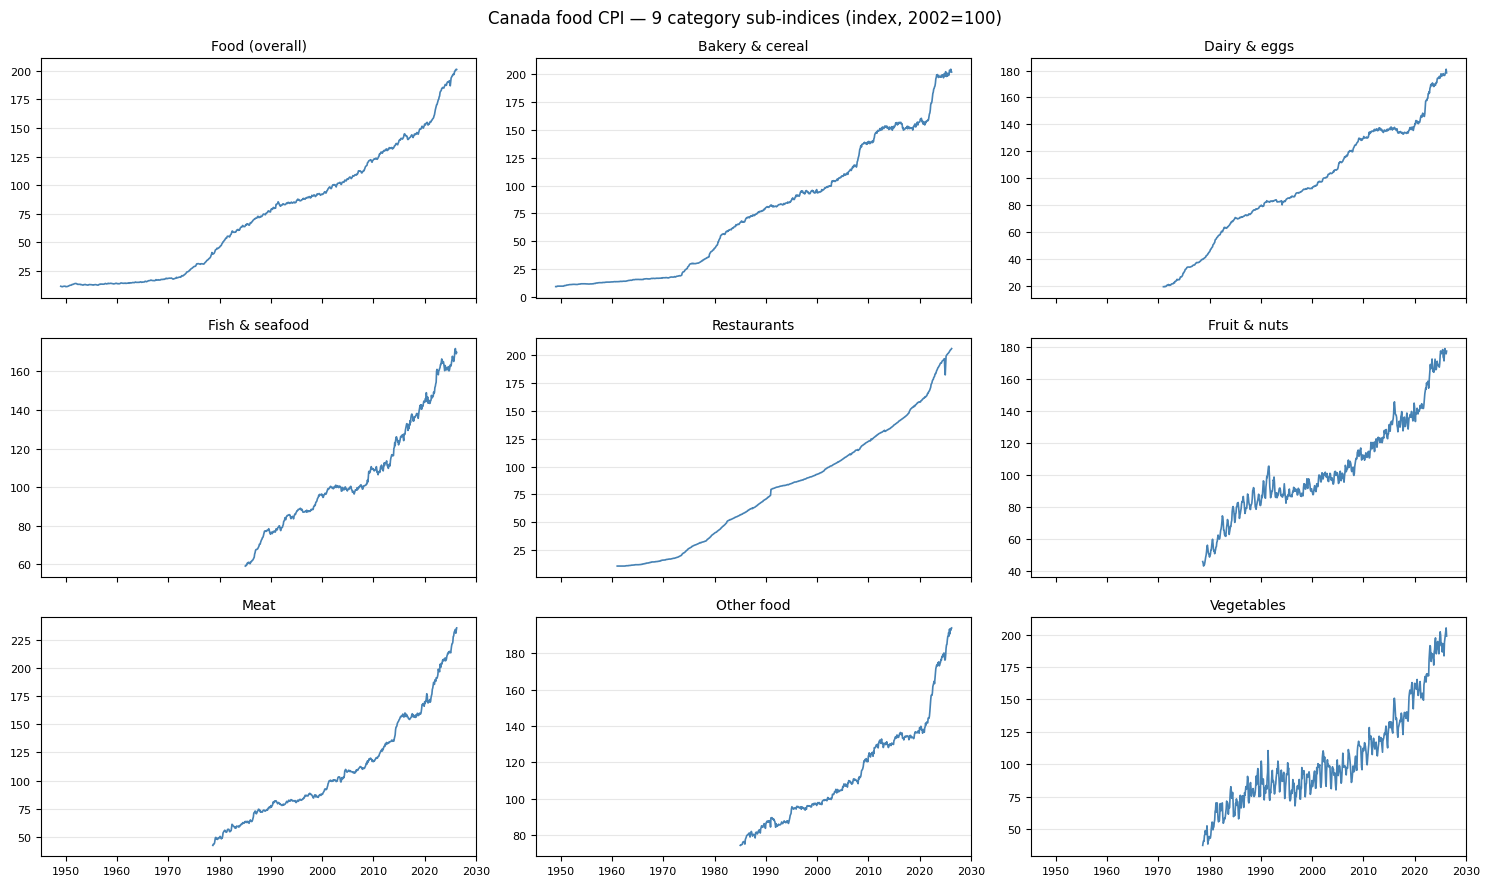

In [3]:
fig, _ = plot_food_cpi_small_multiples(svc)
plt.show()

---
## 3. The backtest spec

The backtest spec is loaded from YAML so the spec (not the notebook) is the
source of truth.  `describe_spec()` renders a plain-text summary suitable for
print, prompts, or documentation.

> **Training window note.** The `full` spec covers origins from July 2009 to
> July 2024.  Gemini's training data extends through late 2024, so virtually
> every origin in this spec — including the most recent ones — falls within the
> model's training window.  The model has plausibly been exposed to resolved
> inflation outcomes for all of these periods.  Keep this in mind when
> interpreting any LLM or agent scores below.

In [4]:
with (SPECS_DIR / _BACKTEST_SPEC_FILE).open() as f:
    backtest_spec = MultiTargetBacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))
print(
    f"\nTasks: {len(backtest_spec.tasks)}  Window: {backtest_spec.start.date()} → {backtest_spec.end.date()}  Stride: {backtest_spec.stride}"
)

MultiTargetBacktestSpec (spec_id=food_cpi_single_mini_backtest)
  description: Single-target mini backtest: bakery & cereal CPI, 6 recent annual July origins (2019-2024), 12-step trajectory (horizons 6-17). Use for fast agent development and pipeline smoke-testing. Not budget-gated — run freely.
  start:       2019-07-01 00:00:00
  end:         2024-07-01 00:00:00
  stride:      12
  warmup:      24
  tasks:       1

Task: food_cpi_bakery_cereal_cfpr
  description: Canada CPI Bakery and cereal products (excl. baby food), trajectory across Jan-Dec of the year following a July origin.
  horizons:    [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17] (len=12)
  frequency:   MS
  payload:     continuous
  resolution:  observed_value_at_resolution_timestamp
- target_series_id: cpi_bakery_cereal_canada
    description:    CPI Bakery and cereal products (excl. baby food), Canada (2002=100)
    source:         Statistics Canada
    units:          Index 2002=100
    frequency:      MS


Tasks: 1  Wi

---
## 4. Predictors

Six active predictors, each implementing the same `Predictor` API against the
configured backtest spec.  The default run stays LLMP-focused: baselines, two
sampled-trajectory LLMP variants, and two quantile-grid runs — one numeric-only
and one **grounded on the CFPR reports themselves**.  Models are the two
bootcamp-pegged Gemini tiers (`gemini-3.1-flash-lite-preview` for the
token-heavy sampled trajectories, `gemini-3.5-flash` for the quantile grids);
pro-tier models are deliberately avoided as too heavy for a notebook run.  The
Food CPI LLMP recipe builders are model-agnostic; model IDs are passed
explicitly and already appear in each `predictor_id`.  Agentic predictors remain
below as commented optional blocks.

| Group | Predictor | Notes |
|---|---|---|
| Baselines | `LastValuePredictor` | Repeats last observed value; hard to beat at short horizons. |
| Baselines | `DartsAutoARIMAPredictor` | Auto-ARIMA via Darts; fits at each origin. |
| LLMP | `SampledTrajectoryLLMPredictor` / Gemini 3.1 Flash-Lite | Samples structured trajectories, then computes empirical quantiles. Token-heavy → lite model. |
| LLMP | `SampledTrajectoryLLMPredictor` / Gemini 3.5 Flash | Same sampled-trajectory contract with the advanced Flash model. |
| LLMP | `QuantileGridLLMPredictor` / Gemini 3.5 Flash | One-shot elicitation of the standard quantile grid. |
| LLMP (reports) | `QuantileGridLLMPredictor` / Gemini 3.5 Flash + CFPR | Same grid, but every CFPR edition published on/before the origin is prepended as text context. One call per origin keeps the large report context affordable. |
| Optional agentic | `AgentPredictor` | Preserved as commented examples; agentic integration lives in the package and can be re-enabled later. |

### Why the quantile grid carries the reports (and not the sampled trajectory)

Report grounding means tens of thousands of input tokens of context per call.
The quantile grid elicits the full distribution in a **single** call per origin,
so that context is paid for once.  A sampled-trajectory variant would re-send the
same reports on every one of its `n_samples` draws — multiplying input-token cost
with no methodological benefit.  Reports therefore ride on the direct-prediction
(quantile-grid) modality by design.

### Leakage — model weights *and* the report itself

Even with tools disabled, a frontier LLM is not a blank slate.  The model
weights encode a compressed representation of its training corpus — which, for
Gemini, includes news, statistics, and economic commentary up to late 2024.  For
a July 2021 origin, the model implicitly "knows" that food inflation spiked in
2022.  This is not a bug that can be filtered away; it is structural.

The report-grounded row compounds this: **the CFPR report for forecast-year Y is
itself an expert narrative forecast of the outcome being scored.**  Feeding it in
is closer to handing the model the answer key than to supplying neutral context.
Treat the `+ CFPR` row strictly as a wiring demonstration and an upper bound — it
shows the document pipeline runs end-to-end and is cutoff-disciplined
(`publication_date <= as_of`), not that report grounding yields live skill.

In [5]:
import pandas as pd
from food_price_forecasting.predictors.llmp_quantile_grid import build_llmp_quantile_grid
from food_price_forecasting.predictors.llmp_sampled_trajectory import build_llmp_sampled_trajectory


# from food_price_forecasting.analyst_agent import build_food_price_agent_predictor


# Bootcamp-pegged Gemini models (see aieng.forecasting.models):
#   gemini-3.1-flash-lite-preview  (LITE_MODEL) — token-heavy workflows, e.g. sampled trajectories
#   gemini-3.5-flash               (ADVANCED_MODEL) — the standard run, e.g. the quantile grids
# Pro-tier models are deliberately avoided here — too heavy for a notebook run.

# ── Baselines ─────────────────────────────────────────────────────────────────
lv = LastValuePredictor()
arima = DartsAutoARIMAPredictor()

# ── Active LLMP predictors (no tools) ─────────────────────────────────────────
# Sampled trajectories are token-heavy (n_samples calls per origin), so they run
# on the lite model; the 3.5-flash variant is a deliberate lite-vs-advanced point.
llmp_sampled_flash_lite = build_llmp_sampled_trajectory(
    model="gemini-3.1-flash-lite-preview",
    n_samples=3,
    history_window=30,
)
llmp_sampled_flash = build_llmp_sampled_trajectory(
    model="gemini-3.5-flash",
    n_samples=3,
    history_window=30,
)
llmp_quantile_grid = build_llmp_quantile_grid(
    model="gemini-3.5-flash",
    history_window=30,
    reasoning_effort="low",
)

# ── Report-grounded LLMP (CFPR editions in context) ───────────────────────────
# The quantile grid is the modality of choice for report grounding: it makes ONE
# elicitation call per origin, so the (large) report context is paid for exactly
# once. Sampled trajectories would re-send the reports on every sample draw, an
# order of magnitude more input tokens for no methodological gain.
#
# `report_sources=["cfpr"]` pulls every CFPR edition the DocumentStore holds with
# publication_date <= the forecast origin and prepends it as a text preamble
# (report_ingestion defaults to "text", which works for Gemini through the proxy;
# native PDF ingestion is Claude/GPT-only today — see the proxy-limitations note).
#
# LEAKAGE, SHARPENED: the CFPR report for forecast-year Y *is the narrative
# forecast of the very outcome being scored*. On historical origins this stacks
# on top of model-weight memorization. Read the report-grounded row as a wiring
# demonstration and an upper bound, never as evidence of live skill.
llmp_quantile_grid_reports = build_llmp_quantile_grid(
    model="gemini-3.5-flash",
    history_window=30,
    reasoning_effort="low",
    report_sources=["cfpr"],
)

# ── Optional agent predictors — news search OFF (historical-backtest safer) ────
# agent_lite = build_food_price_agent_predictor(model="gemini-3.1-flash-lite-preview", enable_news_search=False)
# agent_advanced = build_food_price_agent_predictor(model="gemini-3.5-flash", enable_news_search=False)

# ── Optional agent predictors — news search ON (leakage risk on historical dates) ──
# agent_lite_search = build_food_price_agent_predictor(model="gemini-3.1-flash-lite-preview", enable_news_search=True)
# agent_advanced_search = build_food_price_agent_predictor(model="gemini-3.5-flash", enable_news_search=True)

all_predictors = [
    lv,
    arima,
    llmp_sampled_flash_lite,
    llmp_sampled_flash,
    llmp_quantile_grid,
    llmp_quantile_grid_reports,
    # agent_lite,
    # agent_advanced,
    # agent_lite_search,
    # agent_advanced_search,
]

# Colors: gray/blue = baselines, red = sampled LLMP, purple = quantile grid, orange/green = optional agents
PREDICTOR_COLORS: dict[str, str] = {
    lv.predictor_id: "#7f7f7f",
    arima.predictor_id: "#1f77b4",
    llmp_sampled_flash_lite.predictor_id: "#d62728",
    llmp_sampled_flash.predictor_id: "#e87070",
    llmp_quantile_grid.predictor_id: "#9467bd",
    llmp_quantile_grid_reports.predictor_id: "#c5b0d5",
    # agent_lite.predictor_id: "#ff7f0e",
    # agent_advanced.predictor_id: "#ffb347",
    # agent_lite_search.predictor_id: "#2ca02c",
    # agent_advanced_search.predictor_id: "#72c472",
}

PREDICTOR_LABELS: dict[str, str] = {
    lv.predictor_id: "Naive",
    arima.predictor_id: "AutoARIMA",
    llmp_sampled_flash_lite.predictor_id: "LLMP sampled 3.1 flash-lite",
    llmp_sampled_flash.predictor_id: "LLMP sampled 3.5 flash",
    llmp_quantile_grid.predictor_id: "LLMP quantile-grid 3.5 flash",
    llmp_quantile_grid_reports.predictor_id: "LLMP quantile-grid 3.5 flash + CFPR",
    # agent_lite.predictor_id: "Agent (lite)",
    # agent_advanced.predictor_id: "Agent (advanced)",
    # agent_lite_search.predictor_id: "Agent (lite) + news",
    # agent_advanced_search.predictor_id: "Agent (advanced) + news",
}

for p in all_predictors:
    print(f"  {p.predictor_id}")

  last_value_naive
  darts_autoarima
  llmp_sampled_trajectories_food_cpi_v1_h30_n3[gemini-3.1-flash-lite-preview]
  llmp_sampled_trajectories_food_cpi_v1_h30_n3[gemini-3.5-flash]
  llmp_quantile_grid_food_cpi_v1_h30_rlow[gemini-3.5-flash]
  llmp_quantile_grid_food_cpi_v1_h30_rlow_rep-cfpr[gemini-3.5-flash]


In [6]:
# Optional agent smoke test (disabled for the LLMP-focused notebook run).
# Uncomment this cell only when you want to exercise the Food CPI agent path.
#
# import logging
# import warnings
# from datetime import datetime
#
# from aieng.forecasting.evaluation.task import ForecastingTask
# from aieng.forecasting.langfuse_tracing import init_langfuse_tracing, print_langfuse_trace_url
# from food_price_forecasting.analyst_agent import FoodPriceForecastPromptBuilder, build_food_price_agent_predictor
# from food_price_forecasting.data import build_food_cpi_service
# from food_price_forecasting.smoke_report import CFPR_HORIZONS, summarize_agent_predictions
# from pydantic import ValidationError
#
# warnings.filterwarnings("ignore")
# for _noisy_log in ["opentelemetry", "openinference", "asyncio", "langfuse", "google.adk"]:
#     logging.getLogger(_noisy_log).setLevel(logging.ERROR)
# logging.basicConfig(level=logging.WARNING, format="%(message)s")
# init_langfuse_tracing()
#
# _AGENT_SMOKE_ORIGIN = datetime(2023, 7, 1)
# _AGENT_SMOKE_TASK = ForecastingTask(
#     task_id="meat_cfpr",
#     target_series_id="cpi_meat_canada",
#     horizons=CFPR_HORIZONS,
#     frequency="MS",
#     description="Meat CFPR; Jan-Dec trajectory from July origin.",
# )
# ENABLE_NEWS_SEARCH_SMOKE = True
# _smoke_svc = build_food_cpi_service(cache_dir=STATCAN_CACHE)
# _smoke_predictor = build_food_price_agent_predictor(
#     model="gemini-3.5-flash",
#     enable_news_search=ENABLE_NEWS_SEARCH_SMOKE,
#     prompt_builder=FoodPriceForecastPromptBuilder(max_history_rows=60),
# )
# _ctx = _smoke_svc.context(as_of=_AGENT_SMOKE_ORIGIN)
# _user_msg = _smoke_predictor.prompt_builder(task=_AGENT_SMOKE_TASK, context=_ctx)
# print(_smoke_predictor.agent_config.instruction)
# print(_user_msg)
# try:
#     _smoke_preds = _smoke_predictor.predict(_AGENT_SMOKE_TASK, _ctx)
# except ValidationError:
#     print("SCHEMA VALIDATION FAILED - model response did not match structured output schema.")
#     _smoke_preds = []
# summarize_agent_predictions(_smoke_preds, expected_horizons=CFPR_HORIZONS)
# print_langfuse_trace_url()

---
## 5. Backtest (cached on disk)

`cached_multi_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>/<task_id>.yaml` and reuses it on
subsequent runs.  Pass `force_refresh=True` to re-run a predictor from scratch.

All active predictors run against the configured backtest spec (set in the config cell above).
The two active `SampledTrajectoryLLMPredictor` variants make sampled LLM calls on a first run;
for `mini_recent`, that is 9 targets × 6 origins × 2 LLMPs × 3 samples before caching.
Subsequent runs are free from cache.

**What this backtest is measuring:**

| What we learn | What we don't learn |
|---|---|
| The pipeline runs end-to-end without errors | Whether an LLM can forecast genuinely unseen data |
| The model produces valid calibrated structured output | Whether strong scores reflect skill or memorization |
| An approximate upper bound on live performance | How the method performs when the future is actually unknown |

Think of it this way: a human expert who had already read the outcome would
also beat ARIMA.  The interesting question — whether LLM-process predictors
provide useful calibrated uncertainty when the future is genuinely open — can
only be answered by forecasting tasks that haven't resolved yet.

In [7]:
results_by_predictor: dict[str, dict[str, object]] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results_by_predictor[predictor.predictor_id] = cached_multi_backtest(
        predictor=predictor,
        spec=backtest_spec,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    for task_id, result in results_by_predictor[predictor.predictor_id].items():
        print(f"  {task_id:42s}  mean CRPS = {result.mean_score:.4f}  ({len(result.predictions)} preds)")

Running last_value_naive ...
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 8.1375  (72 preds)
Running darts_autoarima ...
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 8.9225  (72 preds)
Running llmp_sampled_trajectories_food_cpi_v1_h30_n3[gemini-3.1-flash-lite-preview] ...
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 5.9370  (72 preds)
Running llmp_sampled_trajectories_food_cpi_v1_h30_n3[gemini-3.5-flash] ...
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 3.6150  (72 preds)
Running llmp_quantile_grid_food_cpi_v1_h30_rlow[gemini-3.5-flash] ...


Sample 1 parse failure on attempt 1: 1 validation error for _QuantileTrajectory
forecasts
  Field required [type=missing, input_value={'q05': 196.4, 'q10': 196...0': 200.1, 'q95': 200.6}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
Sample 1 parse failure on attempt 2: 1 validation error for _QuantileTrajectory
forecasts
  Field required [type=missing, input_value={'q05': 195.83, 'q10': 19...': 200.4, 'q95': 200.97}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
predict() failed at origin 2024-07-01 (attempt 1/3): No valid quantile-grid response returned by LLM. — retrying in 2s


  food_cpi_bakery_cereal_cfpr                 mean CRPS = 3.0208  (72 preds)
Running llmp_quantile_grid_food_cpi_v1_h30_rlow_rep-cfpr[gemini-3.5-flash] ...
  food_cpi_bakery_cereal_cfpr                 mean CRPS = 3.0870  (72 preds)


---
## 6. Trajectories — focal series

Show the three most recent origins for the focal series (`FOCAL_TASK`, derived
from the first task in the backtest spec) with each predictor's 12-step
trajectory fan.  Solid black is observed history, dashed black is Y+1 actuals
where available, fans are the predictor's 90%/50% intervals with the median in
colour.

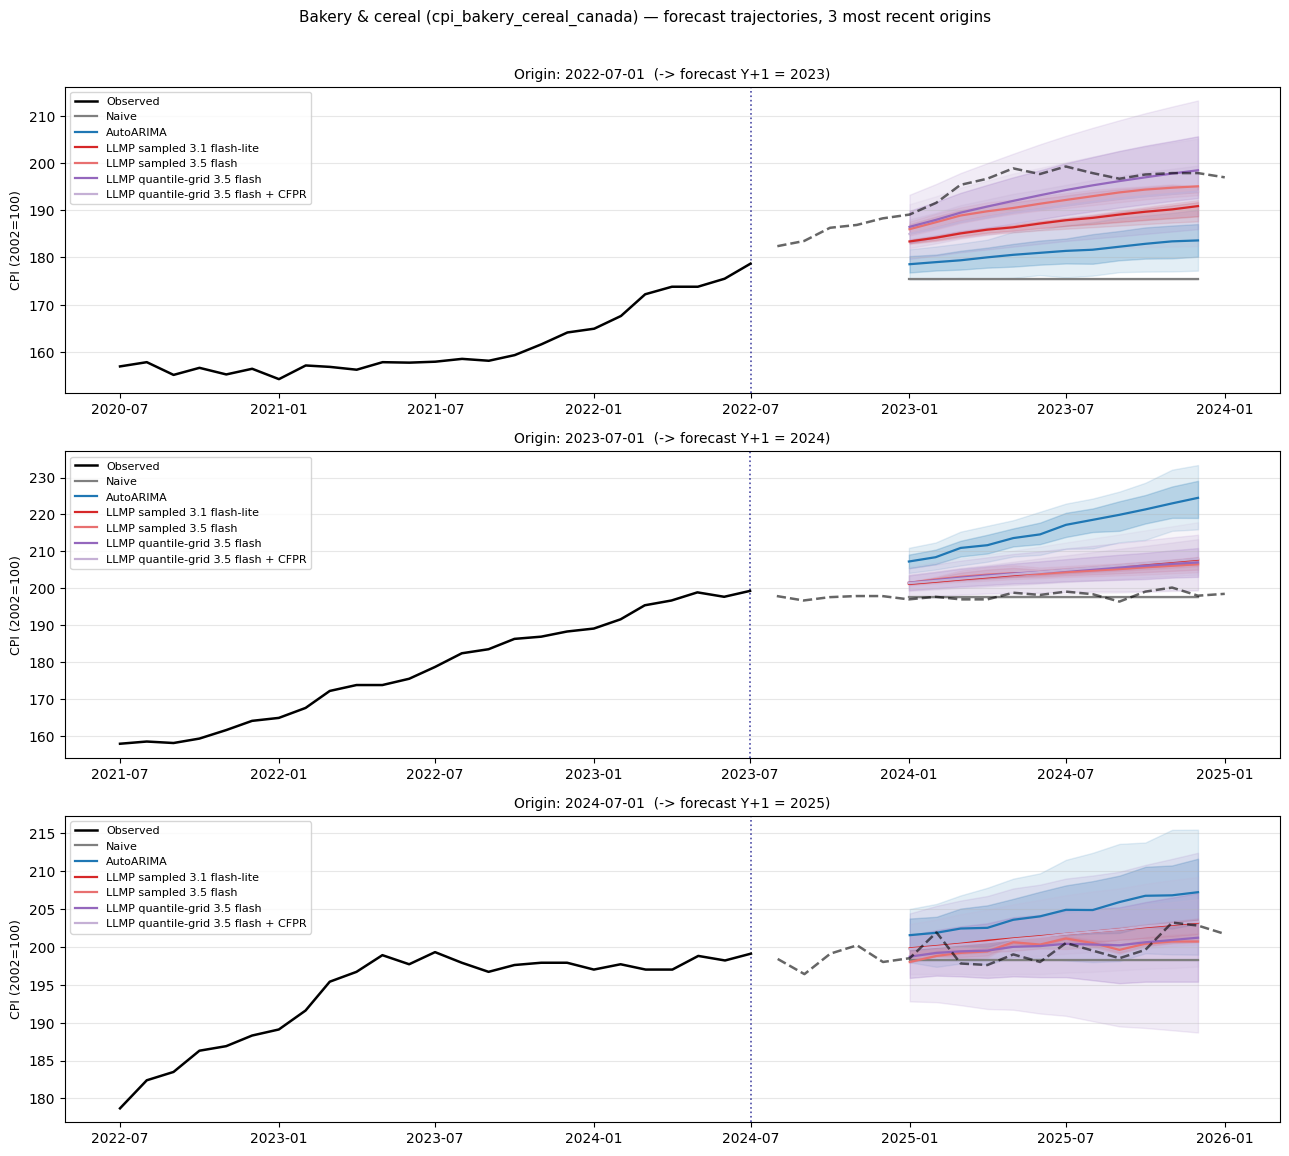

In [8]:
# Derive from the first task in the loaded spec so this adapts to any config.
FOCAL_TASK = backtest_spec.tasks[0].task_id
FOCAL_SERIES = backtest_spec.tasks[0].target_series_id

fig, _ = plot_trajectory_fan(
    results_by_predictor=results_by_predictor,
    task_id=FOCAL_TASK,
    category_id=FOCAL_SERIES,
    data_service=svc,
    n_recent=3,
    colors=PREDICTOR_COLORS,
    labels=PREDICTOR_LABELS,
)
plt.show()

---
## 7. Avg/avg YoY — food CPI categories

The headline CFPR metric: for each July origin, mean predicted CPI for year Y+1
divided by mean observed CPI for year Y, minus 1.  Actual realised YoY (solid
black) is the out-of-sample truth for every completed year.

**Note on the 2022 spike:** Sampled-trajectory LLMPs with
`reasoning_effort="disable"` anchor extrapolation on the *current level* rather
than the *rate of change*, so they can underestimate carry-through during a
mid-surge origin.  This is a known limitation of level-domain direct prompting
(Gruver / CiK), not a data-feeding issue.


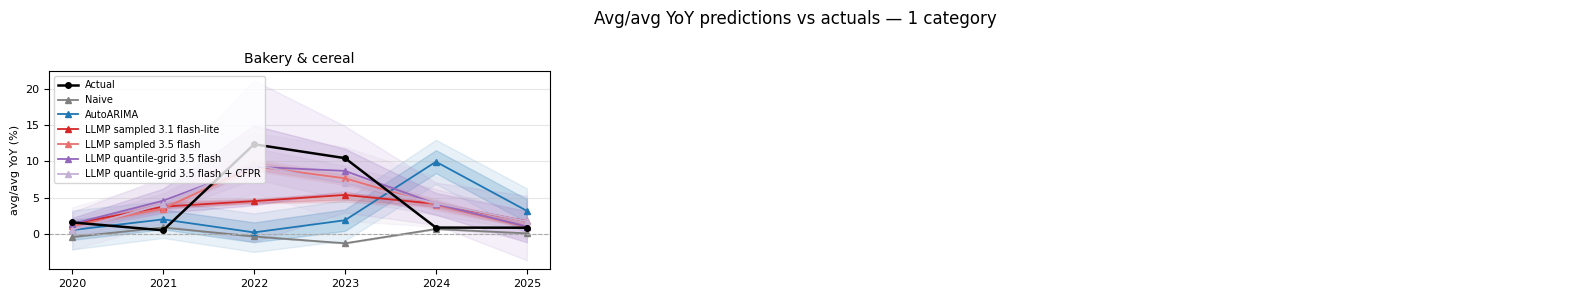

In [9]:
from datetime import datetime, timezone


yoy_by_predictor_by_task: dict[str, dict[str, object]] = {}
task_to_category: dict[str, str] = {task.task_id: task.target_series_id for task in backtest_spec.tasks}

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)

for pid, task_results in results_by_predictor.items():
    yoy_by_predictor_by_task[pid] = {}
    for task_id, result in task_results.items():
        actual_df = svc.get_series(result.spec.task.target_series_id, as_of=_as_of)
        yoy_by_predictor_by_task[pid][task_id] = compute_avgyoy(result, actual_df)

fig, _ = plot_avgyoy_grid(
    yoy_by_predictor_by_task=yoy_by_predictor_by_task,
    task_to_category=task_to_category,
    colors=PREDICTOR_COLORS,
    labels=PREDICTOR_LABELS,
)
plt.show()

---
## 8. Model selection

A note on interpreting scores for LLM-based predictors: because these backtest
origins are within the training window of frontier models, low CRPS values
reflect a combination of (a) genuine calibration quality and (b) the model
"recalling" outcomes it has implicitly seen.  These two contributions cannot be
separated from the backtest alone.  Use the scores to confirm the pipeline is
working and to establish a performance ceiling, not to draw conclusions about
live predictive skill.

### 8.1 CRPS per category

Lower is better.  The `MEAN` row is the across-category average — useful
context, but the per-category rows are the basis for model selection.

In [10]:
crps_board = summarize_crps(results_by_predictor)
print(crps_board.to_string())

predictor_id                 darts_autoarima  last_value_naive  llmp_quantile_grid_food_cpi_v1_h30_rlow[gemini-3.5-flash]  llmp_quantile_grid_food_cpi_v1_h30_rlow_rep-cfpr[gemini-3.5-flash]  llmp_sampled_trajectories_food_cpi_v1_h30_n3[gemini-3.1-flash-lite-preview]  llmp_sampled_trajectories_food_cpi_v1_h30_n3[gemini-3.5-flash]
task_id                                                                                                                                                                                                                                                                                                                                   
food_cpi_bakery_cereal_cfpr           8.9225            8.1375                                                     3.0208                                                               3.087                                                                        5.937                                                           3.615
MEAN   

### 8.2 MAPE per category

Median-accuracy sanity check (CRPS is the primary selection metric).  One panel
per sub-index; each box spans the distribution of per-prediction absolute
percentage errors across all backtest origins and horizons.

predictor_id                 darts_autoarima  last_value_naive  llmp_quantile_grid_food_cpi_v1_h30_rlow[gemini-3.5-flash]  llmp_quantile_grid_food_cpi_v1_h30_rlow_rep-cfpr[gemini-3.5-flash]  llmp_sampled_trajectories_food_cpi_v1_h30_n3[gemini-3.1-flash-lite-preview]  llmp_sampled_trajectories_food_cpi_v1_h30_n3[gemini-3.5-flash]
task_id                                                                                                                                                                                                                                                                                                                                   
food_cpi_bakery_cereal_cfpr            5.467             4.392                                                      2.251                                                               2.482                                                                        3.382                                                           2.202


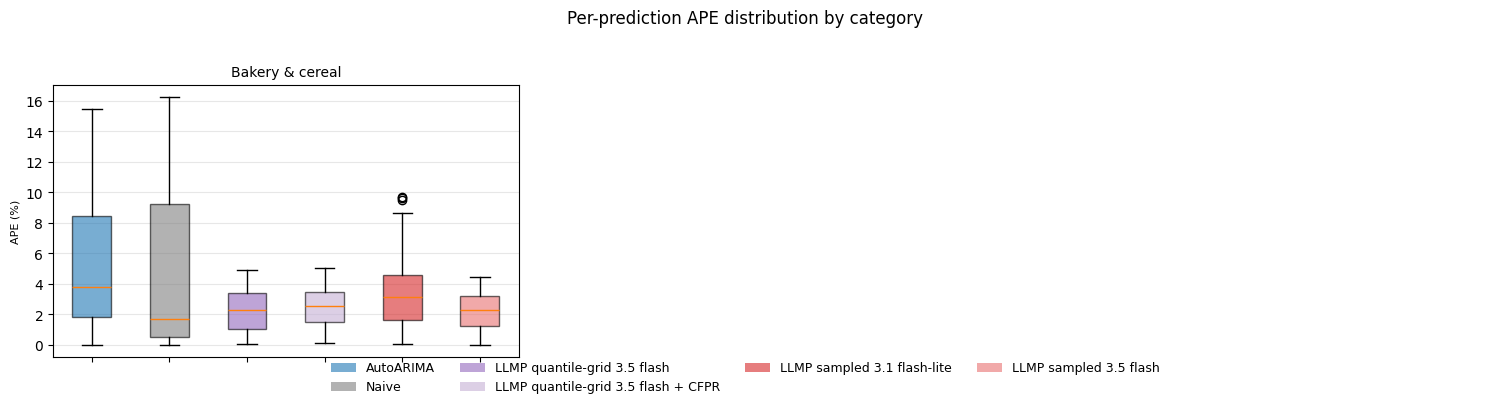

In [11]:
mape_df = compute_mape(results_by_predictor, data_service=svc)
print(mape_df.to_string())

ape_long = compute_ape_long(results_by_predictor, data_service=svc)
fig, _ = plot_mape_by_category(
    ape_long,
    task_to_category=task_to_category,
    colors=PREDICTOR_COLORS,
    labels=PREDICTOR_LABELS,
)
plt.show()

---
## 9. Backtest-average avg/avg YoY — headline table

Model selection is done **per category**: for each food CPI sub-index the
predictor with the lowest mean CRPS over all backtest origins and horizons for
that category is selected independently.  The table below shows each
category's best predictor and its avg/avg YoY central estimate and uncertainty
band averaged across the full backtest window.

In [12]:
# Best predictor per category, selected by that category's own mean CRPS.
best_pid_by_task: dict[str, str] = crps_board.drop(index="MEAN").idxmin(axis=1).to_dict()
print("Best predictor by category (mean CRPS over full backtest window):")
for task_id, pid in best_pid_by_task.items():
    category = CATEGORY_LABELS.get(task_to_category[task_id], task_id)
    print(f"  {category:<40s} {pid}")

rows: list[dict[str, object]] = []
for task_id, pid in best_pid_by_task.items():
    yoy_df = yoy_by_predictor_by_task[pid].get(task_id)
    if yoy_df is None or yoy_df.empty:
        continue
    avg = yoy_df[["yoy_median", "yoy_q05", "yoy_q25", "yoy_q75", "yoy_q95", "actual_yoy"]].mean()
    rows.append(
        {
            "category": CATEGORY_LABELS.get(task_to_category[task_id], task_id),
            "best_predictor": pid,
            "median_yoy_%": round(avg["yoy_median"] * 100, 2),
            "q05_%": round(avg["yoy_q05"] * 100, 2),
            "q25_%": round(avg["yoy_q25"] * 100, 2),
            "q75_%": round(avg["yoy_q75"] * 100, 2),
            "q95_%": round(avg["yoy_q95"] * 100, 2),
            "actual_yoy_%": round(avg["actual_yoy"] * 100, 2),
        }
    )

headline = pd.DataFrame(rows).set_index("category")
print()
print(headline.to_string())

Best predictor by category (mean CRPS over full backtest window):
  Bakery & cereal                          llmp_quantile_grid_food_cpi_v1_h30_rlow[gemini-3.5-flash]

                                                            best_predictor  median_yoy_%  q05_%  q25_%  q75_%  q95_%  actual_yoy_%
category                                                                                                                          
Bakery & cereal  llmp_quantile_grid_food_cpi_v1_h30_rlow[gemini-3.5-flash]          4.83   0.08   2.46   7.32   9.86          4.42


---
## 10. What next — live forecasting as the only clean evaluation

This notebook demonstrates that the LLMP pipeline works: predictors run,
structured output is validated, results are cached, evaluation metrics are
computed.  That is genuinely valuable.  But if the question is "can an LLM
produce useful forecasts of future food prices?", the backtest scores above
cannot answer it.

**The fundamental asymmetry.**  Conventional methods (Last Value, ARIMA) are
blind to the future by construction.  Frontier LLMs are not.  Comparing them on
historical data is a category error — roughly equivalent to asking a human expert
who has already read the economic history to compete against an algorithm that
has not.  The expert will win.  That tells you very little about what either
would do facing a genuinely open question.

**What a clean evaluation looks like.**  The `Predictor` API, `ForecastingTask`,
`BacktestSpec`, and `EvalTracker` (budget-gated evaluation runs) are all
designed to transfer directly to live evaluation:

1. Define tasks whose targets have not yet resolved (e.g., energy price
   forecasts issued today with a 30-day horizon).
2. Lock the predictor configuration and issue forecasts now.
3. Evaluate against actuals when they are published.
4. Compare CRPS against the baselines under identical conditions.

This pattern is demonstrated properly in the **energy prices case study**, where
daily resolution makes genuinely prospective evaluation practical.  Food CPI's
annual resolution cycle makes it unsuitable — you'd wait 18 months for a single
data point.

**The upside case.**  Even acknowledging leakage, the pipeline has demonstrated
something real: LLMs can produce coherent probabilistic forecasts in the required
structured format.  If that capability translates to live tasks — even partially
— it represents a qualitative shift in what is possible with automated
forecasting.  The only way to find out is to forecast forward and measure.

*The next step is to do exactly that.*